In [28]:
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import json

%matplotlib inline

In [6]:
from np_chunker import conll_reader

In [9]:
reader= conll_reader.ConllReader()

In [22]:
import os
import glob
import re

def parse_document(file_content):
    tokens = 0
    sentences = 0
    mentions = 0
    for line in file_content.split('\n'):
        if line.startswith('#begin document'):
            sentences = 0
            tokens = 0
            mentions = 0
        elif line.startswith('#end document'):
            yield tokens, sentences, mentions
        elif line.strip():
            tokens += 1
            if line.strip().startswith('.\t'):
                sentences += 1
            mentions += len(re.findall(r'\(\d+\)', line)) + len(re.findall(r'\(\d+\|\d+\)', line))

def calculate_statistics(data):
    return {
        'average': np.mean(data),
        'median': np.median(data),
        'std': np.std(data),
        'var': np.var(data)
    }

def process_files(folder_path):
    all_tokens = []
    all_sentences = []
    all_mentions = []
    for file_path in glob.glob(os.path.join(folder_path, '*.conllu')):
        with open(file_path, 'r', encoding='utf-8') as file:
            content = file.read()
            for tokens, sentences, mentions in parse_document(content):
                all_tokens.append(tokens)
                all_sentences.append(sentences)
                all_mentions.append(mentions)
    return all_tokens, all_sentences, all_mentions

def main():
    folders = [
        '../corpus/coreference_final_split/gold_splits/with_singleton/train',
        '../corpus/coreference_final_split/gold_splits/with_singleton/dev',
        '../corpus/coreference_final_split/gold_splits/with_singleton/test',
    ]

    combined_tokens = []
    combined_sentences = []
    combined_mentions = []

    for folder in folders:
        tokens, sentences, mentions = process_files(folder)
        combined_tokens.extend(tokens)
        combined_sentences.extend(sentences)
        combined_mentions.extend(mentions)

        print(f'Statistics for {folder}:')
        print('Tokens:', calculate_statistics(tokens))
        print('Sentences:', calculate_statistics(sentences))
        print('Mentions:', calculate_statistics(mentions))
        print()

    print('Combined Statistics:')
    print('Tokens:', calculate_statistics(combined_tokens))
    print('Sentences:', calculate_statistics(combined_sentences))
    print('Mentions:', calculate_statistics(combined_mentions))



Statistics for Train:
----------------------------------------
Tokens: {
    "average": 456.25581395348837,
    "median": 386.0,
    "std": 270.78285241845055,
    "var": 73323.35316387237
}
Sentences: {
    "average": 17.089700996677742,
    "median": 16.0,
    "std": 9.364983565727412,
    "var": 87.70291718634452
}
Mentions: {
    "average": 39.82392026578073,
    "median": 33.0,
    "std": 27.63764512075667,
    "var": 763.8394278208849
}


Statistics for Dev:
----------------------------------------
Tokens: {
    "average": 402.84615384615387,
    "median": 344.5,
    "std": 207.04936095004612,
    "var": 42869.43786982248
}
Sentences: {
    "average": 16.076923076923077,
    "median": 15.5,
    "std": 8.453142687886864,
    "var": 71.45562130177515
}
Mentions: {
    "average": 36.53846153846154,
    "median": 34.5,
    "std": 22.075448892083312,
    "var": 487.32544378698225
}


Statistics for Test:
----------------------------------------
Tokens: {
    "average": 507.0,
    "me

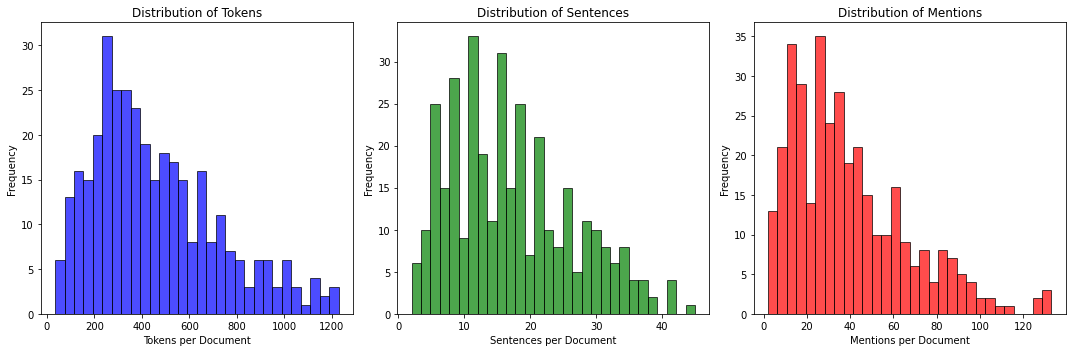

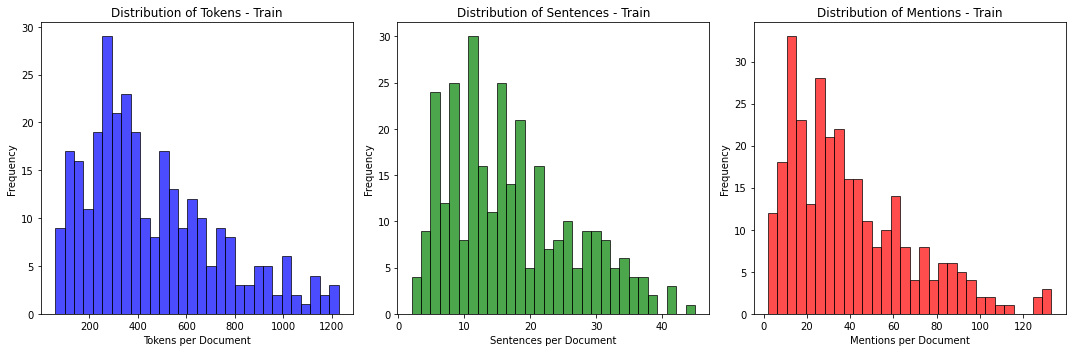

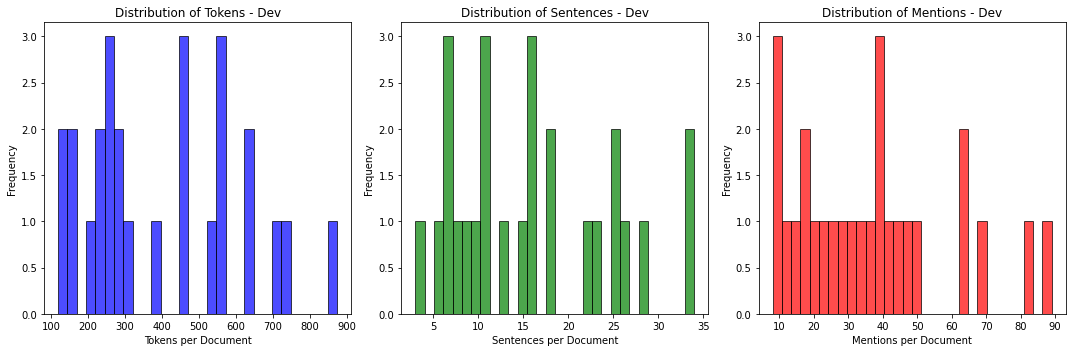

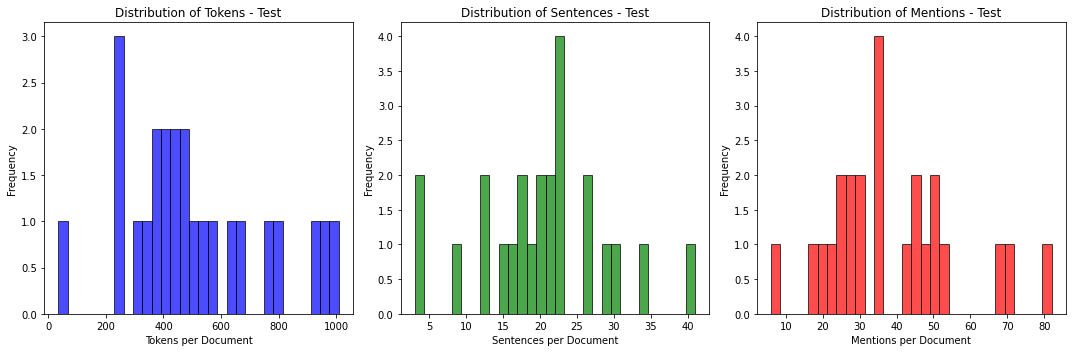


Statistics for Combined:
----------------------------------------
Tokens: {
    "average": 455.7692307692308,
    "median": 393.0,
    "std": 265.2970721458341,
    "var": 70382.53648915188
}
Sentences: {
    "average": 17.22792022792023,
    "median": 16.0,
    "std": 9.282794546467514,
    "var": 86.17027459192703
}
Mentions: {
    "average": 39.47863247863248,
    "median": 34.0,
    "std": 26.700277415867824,
    "var": 712.9048140843013
}



In [30]:
def plot_statistics(tokens, sentences, mentions, dataset_labels, dataset_stats):
    plt.figure(figsize=(15, 5))

    # Plot tokens distribution
    plt.subplot(1, 3, 1)
    plt.hist(tokens, bins=30, color='blue', alpha=0.7, edgecolor='black')
    plt.xlabel('Tokens per Document')
    plt.ylabel('Frequency')
    plt.title('Distribution of Tokens')

    # Plot sentences distribution
    plt.subplot(1, 3, 2)
    plt.hist(sentences, bins=30, color='green', alpha=0.7, edgecolor='black')
    plt.xlabel('Sentences per Document')
    plt.ylabel('Frequency')
    plt.title('Distribution of Sentences')

    # Plot mentions distribution
    plt.subplot(1, 3, 3)
    plt.hist(mentions, bins=30, color='red', alpha=0.7, edgecolor='black')
    plt.xlabel('Mentions per Document')
    plt.ylabel('Frequency')
    plt.title('Distribution of Mentions')

    plt.tight_layout()
    plt.show()

    # Create individual plots for each dataset
    for i, label in enumerate(dataset_labels):
        tokens, sentences, mentions = dataset_stats[i]
        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.hist(tokens, bins=30, color='blue', alpha=0.7, edgecolor='black')
        plt.xlabel('Tokens per Document')
        plt.ylabel('Frequency')
        plt.title(f'Distribution of Tokens - {label}')

        plt.subplot(1, 3, 2)
        plt.hist(sentences, bins=30, color='green', alpha=0.7, edgecolor='black')
        plt.xlabel('Sentences per Document')
        plt.ylabel('Frequency')
        plt.title(f'Distribution of Sentences - {label}')

        plt.subplot(1, 3, 3)
        plt.hist(mentions, bins=30, color='red', alpha=0.7, edgecolor='black')
        plt.xlabel('Mentions per Document')
        plt.ylabel('Frequency')
        plt.title(f'Distribution of Mentions - {label}')

        plt.tight_layout()
        plt.show()
def pretty_print_statistics(label, tokens, sentences, mentions):
    print(f"\n{'='*40}")
    print(f"Statistics for {label}:")
    print(f"{'-'*40}")
    print("Tokens:", json.dumps(calculate_statistics(tokens), indent=4))
    print("Sentences:", json.dumps(calculate_statistics(sentences), indent=4))
    print("Mentions:", json.dumps(calculate_statistics(mentions), indent=4))
    print(f"{'='*40}\n")

# Example usage after processing files
def plot_all():
    folders = [
        '../corpus/coreference_final_split/gold_splits/with_singleton/train',
        '../corpus/coreference_final_split/gold_splits/with_singleton/dev',
        '../corpus/coreference_final_split/gold_splits/with_singleton/test',
    ]
    dataset_labels = ['Train', 'Dev', 'Test']
    dataset_stats = []

    combined_tokens = []
    combined_sentences = []
    combined_mentions = []

    for folder, label in zip(folders, dataset_labels):
        tokens, sentences, mentions = process_files(folder)
        dataset_stats.append((tokens, sentences, mentions))
        combined_tokens.extend(tokens)
        combined_sentences.extend(sentences)
        combined_mentions.extend(mentions)
        pretty_print_statistics(label, tokens, sentences, mentions)

    plot_statistics(combined_tokens, combined_sentences, combined_mentions, dataset_labels, dataset_stats)
    pretty_print_statistics("Combined", combined_tokens, combined_sentences, combined_mentions)

plot_all()



In [23]:
main()

Statistics for ../corpus/coreference_final_split/gold_splits/with_singleton/train:
Tokens: {'average': 456.25581395348837, 'median': 386.0, 'std': 270.78285241845055, 'var': 73323.35316387237}
Sentences: {'average': 17.089700996677742, 'median': 16.0, 'std': 9.364983565727412, 'var': 87.70291718634452}
Mentions: {'average': 39.82392026578073, 'median': 33.0, 'std': 27.63764512075667, 'var': 763.8394278208849}

Statistics for ../corpus/coreference_final_split/gold_splits/with_singleton/dev:
Tokens: {'average': 402.84615384615387, 'median': 344.5, 'std': 207.04936095004612, 'var': 42869.43786982248}
Sentences: {'average': 16.076923076923077, 'median': 15.5, 'std': 8.453142687886864, 'var': 71.45562130177515}
Mentions: {'average': 36.53846153846154, 'median': 34.5, 'std': 22.075448892083312, 'var': 487.32544378698225}

Statistics for ../corpus/coreference_final_split/gold_splits/with_singleton/test:
Tokens: {'average': 507.0, 'median': 462.5, 'std': 240.09130207763323, 'var': 57643.833333